In [4]:
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Callable

f64 = np.float64
f64arr = np.typing.NDArray[f64]

In [38]:
def approx_sol_euler(yp: Callable[[f64, f64], f64], t: f64arr, y0: f64) -> f64arr:
    y = np.zeros(t.size, dtype=f64)
    y[0] = y0

    for i in range(1, y.size):
        y[i] = y[i-1] + (t[i] - t[i-1]) * yp(t[i-1], y[i-1])
    return y
    
def approx_sol_heun(yp: Callable[[f64, f64], f64], t: f64arr, y0: f64) -> f64arr:
    y = np.zeros(t.size, dtype=f64)
    y[0] = y0

    for i in range(1, y.size):
        pred = y[i-1] + (t[i] - t[i-1]) * yp(t[i-1], y[i-1])
        y[i] = y[i-1] + (t[i] - t[i-1])/2 * (yp(t[i-1], y[i-1]) + yp(t[i], pred))
    return y
    
def approx_sol(yp: Callable[[f64, f64], f64], t0: f64, L: f64, y0: f64):
    divs = [1, 2, 4, 8, 16]
    colors_euler = ["#f6bdc0", "#f1959b", "#f07470", "#ea4c46", "#dc1c13"]
    colors_heun = ["#bfbfff", "#a3a3ff", "#7879ff", "#4949ff", "#1f1fff"]
    for div, col_e, col_h in zip(divs, colors_euler, colors_heun):
        t = np.linspace(t0, t0 + L, div*10 + 1)
        plt.plot(t, approx_sol_euler(yp, t, y0), label=f"Euler h=L/{div*10}", c=col_e, lw=1)
        plt.plot(t, approx_sol_heun(yp, t, y0), label=f"Heun h=L/{div*10}", c=col_h, lw=1)

def plot_sol(y: Callable[f64, f64], t0: f64, L: f64):
    t = np.linspace(t0, t0 + L)
    plt.plot(t, y(t), label="Actual", c="black", lw=1)

def plot_error(yp: Callable[f64, f64], y: Callable[f64, f64], t0: f64, L: f64, y0: f64, divrange: tuple(int, int), local: bool):
    divs = np.arange(divrange[0], divrange[1] + 1)
    euler = np.zeros(divs.size, dtype=f64)
    heun = np.zeros(divs.size, dtype=f64)
    for i, div in enumerate(divs):
        t = np.linspace(t0, t0 + (L/2 if local else L), div * (5 if local else 10) + 1)
        euler[i] = approx_sol_euler(yp, t, y0)[-1]
        heun[i] = approx_sol_heun(yp, t, y0)[-1]
    y_acc = y(t0 + (L/2 if local else L))
    euler = np.abs(euler - y_acc)
    heun = np.abs(heun - y_acc)
    h = L / (10 * divs)
    plt.plot(h, euler, label="Euler", c="red")
    plt.plot(h, heun, label="Heun", c="blue")

def plot_ODE(yp: Callable[f64, f64], y: Callable[f64, f64], t0: f64, L: f64, y0: f64, title: str, ylog: bool = False):
    approx_sol(yp, t0, L, y0)
    plot_sol(y, t0, L)
    plt.legend()
    if ylog:
        plt.yscale("log")
    plt.title(title)
    plt.xlabel("t")
    plt.ylabel("y")
    plt.show()

    plot_error(yp, y, t0, L, y0, (1, 100), True)
    plt.xscale("log")
    plt.yscale("log")
    plt.legend()
    plt.title(f"{title} - Local Error @ {t0 + L/2:.2f}")
    plt.xlabel("h")
    plt.ylabel("Absolute Error")
    plt.show()

    plot_error(yp, y, t0, L, y0, (1, 100), False)
    plt.xscale("log")
    plt.yscale("log")
    plt.legend()
    plt.title(f"{title} - Global Error @ {t0 + L:.2f}")
    plt.xlabel("h")
    plt.ylabel("Absolute Error")
    plt.show()

# Daniel Li ODEs
## 4
ODE: $y' - 2y = \sin(t/2)$ \
Interval: $[0, 4 \pi]$ \
Initial Value: $y(0) = 0$
### Analytical Solution
#### Homogeneous
$y'_c - 2y_c = 0, y_c = c e^{rt} \rightarrow r - 2 = 0$ \
$\quad \rightarrow y_c = c e^{2t}$
#### Particular
$y_p = A\cos(t/2) + B\sin(t/2)$ \
$\quad \rightarrow y'_p = -\frac{A}{2}\sin(t/2) + \frac{B}{2}\cos(t/2)$ \
$y'_p - 2y_p = -\frac{A}{2}\sin(t/2) + \frac{B}{2}\cos(t/2) - 2A\cos(t/2) - 2B\sin(t/2) = \sin(t/2)$ \
$\quad \rightarrow -\frac{A}{2} - 2B = 1, \frac{B}{2} - 2A = 0 \rightarrow A = -\frac{2}{17}, B = -\frac{8}{17}$ \
$\quad \rightarrow y_p = -\frac{2}{17}\cos(t/2) - \frac{8}{17}\sin(t/2)$
#### General Solution
$y = y_c + y_p = c e^{2t} - \frac{2}{17}\cos(t/2) - \frac{8}{17}\sin(t/2)$
#### Apply Initial Value
$y(0) = c - \frac{2}{17} = 0 \rightarrow c = \frac{2}{17}$ \
$\quad \rightarrow y = \frac{2}{17}e^{2t} - \frac{2}{17}\cos(t/2) - \frac{8}{17}\sin(t/2)$

Explicit Analytical Solution: $y = \frac{2}{17}e^{2t} - \frac{2}{17}\cos(t/2) - \frac{8}{17}\sin(t/2)$

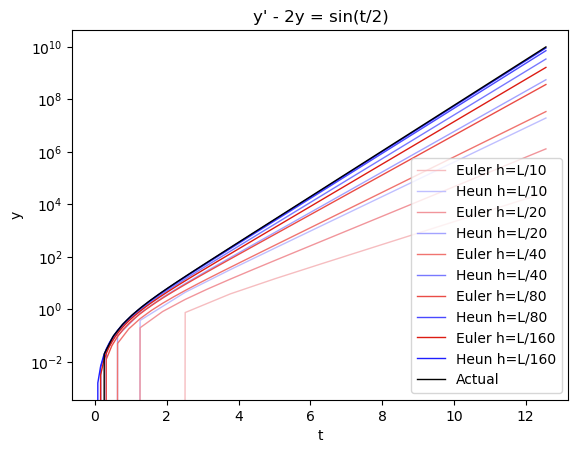

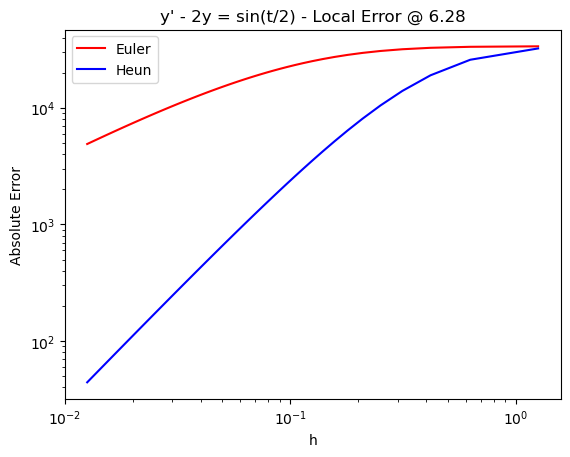

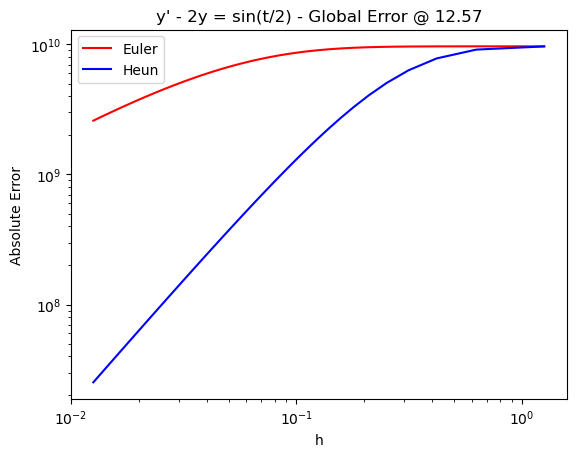

In [39]:
plot_ODE(
    yp=lambda t, y: np.sin(t/2) + 2 * y,
    y=lambda t: (2/17)*np.exp(2*t) - (2/17)*np.cos(t/2) - (8/17)*np.sin(t/2),
    t0=0,
    L=4*np.pi,
    y0=0,
    title="y' - 2y = sin(t/2)",
    ylog=True
)

### 8
ODE: $y' + y = 3e^{-t}$ \
Interval: $[0, 1]$ \
Initial Value: $y(0) = 1$
### Analytical Solution
#### Homogeneous
$y'_c + y_c = 0, y_c = ce^{rt} \rightarrow r + 1 = 0$ \
$\quad \rightarrow y_c = ce^{-t}$
#### Particular
$y_p = Ate^{-t}$ \
$\quad \rightarrow y'_p = Ae^{-t} - Ate^{-t}$ \
$y'_p + y_p = Ae^{-t} - Ate^{-t} + Ate^{-t} = Ae^{-t} = 3e^{-t} \rightarrow A = 3$ \
$\quad \rightarrow y_p = 3te^{-t}$
#### General Solution
$y = y_c + y_p = ce^{-t} + 3te^{-t}$
#### Apply Initial Value
$y(0) = c + 0 = 1 \rightarrow y = e^{-t} + 3te^{-t}$

Explicit Analytical Solution: $y = e^{-t} + 3te^{-t}$

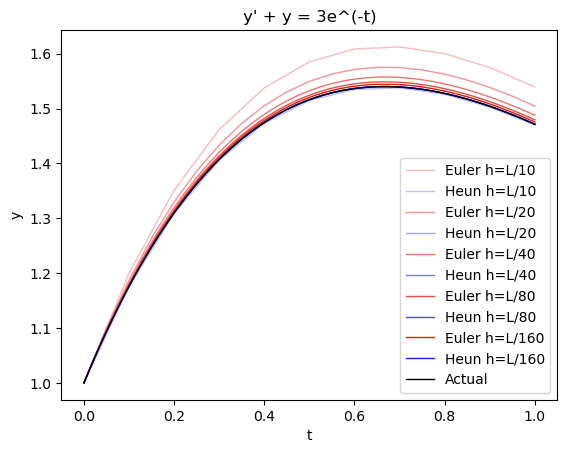

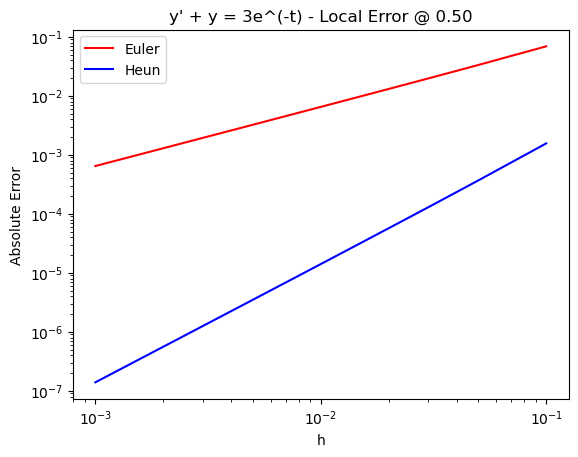

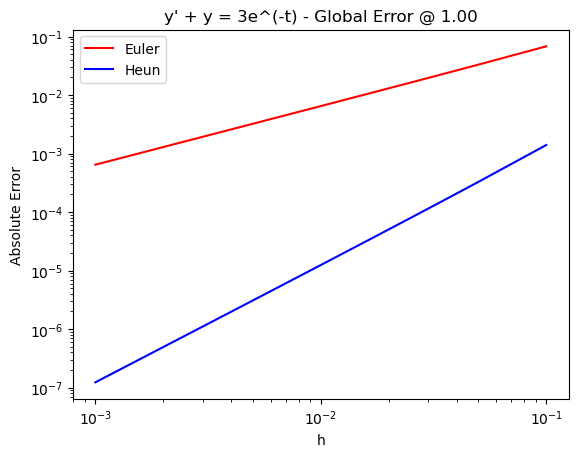

In [40]:
plot_ODE(
    yp=lambda t, y: 3*np.exp(-t) - y,
    y=lambda t: np.exp(-t) + 3*t*np.exp(-t),
    t0=0,
    L=1,
    y0=1,
    title="y' + y = 3e^(-t)",
)

### 12
ODE: $y' + y = t^2 + 2t + 1$ \
Interval: $[0, 1]$ \
Initial Value: $y(0) = 1$
### Analytical Solution
#### Homogeneous
$y'_c + y_c = 0, y_c = ce^{rt} \rightarrow r + 1 = 0$ \
$\quad \rightarrow y_c = ce^{-t}$
#### Particular
$y_p = At^2 + Bt + C$ \
$\quad \rightarrow y'_p = 2At + B$ \
$y'_p + y_p = At^2 + (2A+B)t + (B+C) = t^2 + 2t + 1 \rightarrow A = 1, B = 0, C = 1$ \
$\quad \rightarrow y_p = t^2 + 1$
#### General Solution
$y = y_c + y_p = ce^{-t} + t^2 + 1$
#### Apply Initial Value
$y(0) = c + 1 = 1 \rightarrow y = t^2 + 1$

Explicit Analytical Solution: $y = t^2 + 1$

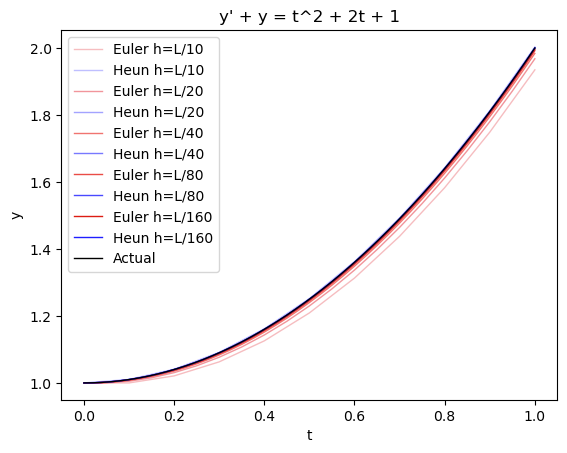

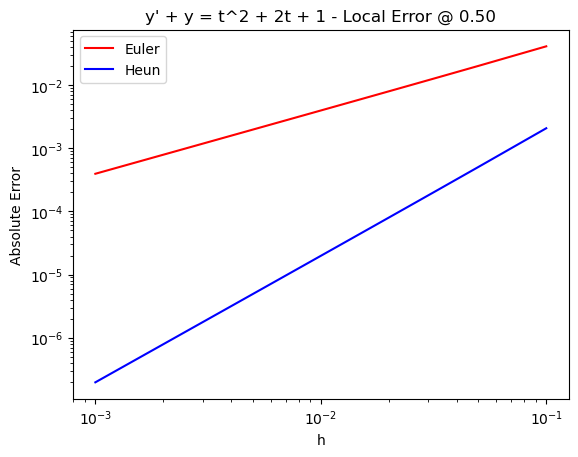

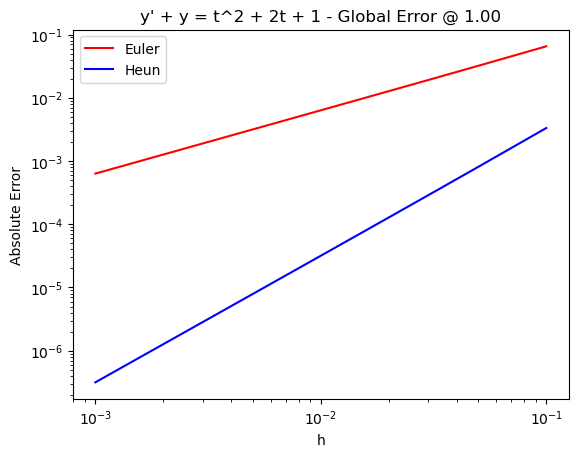

In [41]:
plot_ODE(
    yp=lambda t, y: t*t + 2*t + 1 - y,
    y=lambda t: t*t + 1,
    t0=0,
    L=1,
    y0=1,
    title="y' + y = t^2 + 2t + 1",
)